<a href="https://colab.research.google.com/github/rinkamonicputri-collab/HasilPrediksiDating/blob/main/datmin_lomba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama TIM : DATING WELL
Nama Anggota:
1. Hindun Fadilah Salafi (2304020112)
2. Rinkamonic Putri Alfajri (2304020147)
3. Ameilya Anggie Dyah Risyadi (2304020149)

Install dan Import Library

In [13]:
# Install library tambahan jika diperlukan
!pip install -q lightgbm xgboost scikit-learn pandas numpy matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
import lightgbm as lgb

print('✅ Semua library berhasil di-import!')
print(f'   LightGBM version : {lgb.__version__}')
print(f'   Pandas version   : {pd.__version__}')
print(f'   Numpy version    : {np.__version__}')

✅ Semua library berhasil di-import!
   LightGBM version : 4.6.0
   Pandas version   : 2.2.2
   Numpy version    : 2.0.2


Upload dan Muat Dataset

In [14]:
# Upload file train.csv dan test.csv ke Google Colab
from google.colab import files

print('📤 Silakan upload file train.csv dan test.csv ...')
uploaded = files.upload()
print(f'\n✅ File yang diupload: {list(uploaded.keys())}')

📤 Silakan upload file train.csv dan test.csv ...


Saving test (1).csv to test (1).csv
Saving train (1).csv to train (1).csv

✅ File yang diupload: ['test (1).csv', 'train (1).csv']


In [15]:
uploaded_names = list(uploaded.keys())

train_file = next((f for f in uploaded_names if 'train' in f.lower()), None)
test_file  = next((f for f in uploaded_names if 'test'  in f.lower()), None)

if train_file is None:
    raise ValueError(f'File train tidak ditemukan. File diupload: {uploaded_names}')

train_df = pd.read_csv(train_file)
print(f'Train dimuat dari: {train_file}')

if test_file:
    test_df  = pd.read_csv(test_file)
    HAS_TEST = True
    print(f'Test dimuat dari: {test_file}')
else:
    print('PERINGATAN: test.csv tidak ditemukan, pakai 20% train sebagai dummy.')
    train_df, test_df = train_test_split(train_df, test_size=0.2, random_state=0)
    train_df = train_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)
    HAS_TEST = False

print(f'\nTraining set : {train_df.shape[0]:,} baris x {train_df.shape[1]} kolom')
print(f'Testing set  : {test_df.shape[0]:,} baris x {test_df.shape[1]} kolom')
train_df.head()

Train dimuat dari: train (1).csv
Test dimuat dari: test (1).csv

Training set : 78,772 baris x 47 kolom
Testing set  : 42,422 baris x 20 kolom


,Id,match_id,date,gender,team,opponent,is_home,neutral,tournament,venue_country,...,confederation_team,confederation_opp,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp,altitude_venue,distance_travel_team,distance_travel_opp,temperature_venue
0,M000001_Scotland,M000001,1872-11-30,M,Scotland,England,1,0,Friendly,Scotland,...,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M000001_England,M000001,1872-11-30,M,England,Scotland,0,0,Friendly,Scotland,...,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,M000002_England,M000002,1873-03-08,M,England,Scotland,1,0,Friendly,England,...,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,M000002_Scotland,M000002,1873-03-08,M,Scotland,England,0,0,Friendly,England,...,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,M000003_Scotland,M000003,1874-03-07,M,Scotland,England,1,0,Friendly,Scotland,...,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Feature Engineering dan Preprocessing

In [16]:
TARGET_COLS = ['team_goals', 'opp_goals']

ALL_NUM_FEATS = [
    'is_home', 'neutral',
    'population_team', 'population_opp',
    'gdp_per_capita_team', 'gdp_per_capita_opp',
    'altitude_venue', 'distance_travel_team',
    'distance_travel_opp', 'temperature_venue',
    # Fitur statistik (hanya ada jika test punya kolom ini)
    'team_points_last5', 'opp_points_last5', 'points_last5_diff',
    'team_gd_last5', 'opp_gd_last5', 'gd_last5_diff',
    'h2h_points_last5', 'h2h_gd_last5',
    'days_since_last_match_team', 'days_since_last_match_opp',
    'team_points_last10', 'opp_points_last10',
    'team_avg_goals_last5', 'team_avg_conceded_last5',
    'opp_avg_goals_last5', 'opp_avg_conceded_last5',
    'team_win_rate_last10', 'opp_win_rate_last10',
    'elo_team', 'elo_opponent',
    'rank_team', 'rank_opponent', 'rank_diff',
    'rank_missing_team', 'rank_missing_opp',
]

ALL_CAT_FEATS = ['gender', 'tournament', 'confederation_team', 'confederation_opp']

# Hanya gunakan kolom yang ada di KEDUA dataset
both_cols = set(test_df.columns) & set(train_df.columns)
NUM_FEATS = [c for c in ALL_NUM_FEATS  if c in both_cols]
CAT_FEATS = [c for c in ALL_CAT_FEATS if c in both_cols]

print(f'Fitur numerik    : {len(NUM_FEATS)}')
print(f'Fitur kategorikal: {len(CAT_FEATS)}')
print('Numerik :', NUM_FEATS)
print('Kategori:', CAT_FEATS)

Fitur numerik    : 10
Fitur kategorikal: 4
Numerik : ['is_home', 'neutral', 'population_team', 'population_opp', 'gdp_per_capita_team', 'gdp_per_capita_opp', 'altitude_venue', 'distance_travel_team', 'distance_travel_opp', 'temperature_venue']
Kategori: ['gender', 'tournament', 'confederation_team', 'confederation_opp']


In [17]:
# Encode kategorikal — fit pada gabungan train+test
le_dict = {}
for col in CAT_FEATS:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]], axis=0).fillna('Unknown')
    le.fit(combined.astype(str))
    le_dict[col] = le
    train_df[col + '_enc'] = le.transform(train_df[col].fillna('Unknown').astype(str))
    test_df[col  + '_enc'] = le.transform(test_df[col].fillna('Unknown').astype(str))

CAT_FEATS_ENC = [c + '_enc' for c in CAT_FEATS]
FINAL_FEATS   = NUM_FEATS + CAT_FEATS_ENC
print(f'Total fitur final: {len(FINAL_FEATS)}')

Total fitur final: 14


In [18]:
X           = train_df[FINAL_FEATS].copy()
y           = train_df[TARGET_COLS].copy()
X_test_full = test_df[FINAL_FEATS].copy()

# Split train/val
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Imputer: fit HANYA pada X_train
imputer     = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=FINAL_FEATS)
X_val_imp   = pd.DataFrame(imputer.transform(X_val),       columns=FINAL_FEATS)
X_test_imp  = pd.DataFrame(imputer.transform(X_test_full), columns=FINAL_FEATS)

print(f'X_train: {X_train_imp.shape}, X_val: {X_val_imp.shape}, X_test: {X_test_imp.shape}')

# Info kelas
for col in TARGET_COLS:
    n_all   = y[col].nunique()
    n_train = y_train[col].nunique()
    missing = sorted(set(y[col].unique()) - set(y_train[col].unique()))
    print(f'{col}: total {n_all} kelas, train {n_train} kelas, tidak ada di train: {missing}')

X_train: (63017, 14), X_val: (15755, 14), X_test: (42422, 14)
team_goals: total 26 kelas, train 26 kelas, tidak ada di train: []
opp_goals: total 26 kelas, train 24 kelas, tidak ada di train: [np.int64(30), np.int64(31)]


Model LightGBM

In [19]:
# num_class dari y KESELURUHAN (bukan y_train)
N_CLASSES_TEAM = int(y['team_goals'].max()) + 1
N_CLASSES_OPP  = int(y['opp_goals'].max())  + 1

print(f'Kelas team_goals: 0 s.d. {N_CLASSES_TEAM-1} ({N_CLASSES_TEAM} kelas)')
print(f'Kelas opp_goals : 0 s.d. {N_CLASSES_OPP-1}  ({N_CLASSES_OPP} kelas)')

lgb_params_base = dict(
    objective         = 'multiclass',
    metric            = 'multi_logloss',
    boosting_type     = 'gbdt',
    n_estimators      = 500,
    learning_rate     = 0.05,
    num_leaves        = 63,
    max_depth         = -1,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 0.1,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)

# =====================================================================
# FUNGSI KUNCI: clip label eval_set ke max label yang ada di y_train
# agar LightGBM tidak menemui 'unseen labels' saat validasi.
# Kelas langka yang di-clip tetap diprediksi dengan benar pada predict()
# karena num_class sudah mencakup semua kelas dari y keseluruhan.
# =====================================================================
def make_safe_eval_set(y_train_col, y_val_col, X_val_imp):
    max_train_label = int(y_train_col.max())
    y_val_clipped   = y_val_col.clip(upper=max_train_label)
    n_clipped       = (y_val_col > max_train_label).sum()
    if n_clipped > 0:
        print(f'  INFO: {n_clipped} sampel val di-clip (label > {max_train_label})')
    return [(X_val_imp, y_val_clipped.reset_index(drop=True))]

Kelas team_goals: 0 s.d. 31 (32 kelas)
Kelas opp_goals : 0 s.d. 31  (32 kelas)


In [20]:
# Latih model team_goals
print('Melatih model team_goals ...')

eval_team = make_safe_eval_set(
    y_train['team_goals'], y_val['team_goals'], X_val_imp
)

model_team = lgb.LGBMClassifier(**lgb_params_base, num_class=N_CLASSES_TEAM)
model_team.fit(
    X_train_imp,
    y_train['team_goals'].reset_index(drop=True),
    eval_set=eval_team,
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100)
    ]
)
print(f'Model team_goals selesai! Best iteration: {model_team.best_iteration_}')

Melatih model team_goals ...
[100]	valid_0's multi_logloss: 1.60282
Model team_goals selesai! Best iteration: 72


In [21]:
# Latih model opp_goals
print('Melatih model opp_goals ...')

eval_opp = make_safe_eval_set(
    y_train['opp_goals'], y_val['opp_goals'], X_val_imp
)

model_opp = lgb.LGBMClassifier(**lgb_params_base, num_class=N_CLASSES_OPP)
model_opp.fit(
    X_train_imp,
    y_train['opp_goals'].reset_index(drop=True),
    eval_set=eval_opp,
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100)
    ]
)
print(f'Model opp_goals selesai! Best iteration: {model_opp.best_iteration_}')

Melatih model opp_goals ...
  INFO: 2 sampel val di-clip (label > 24)
[100]	valid_0's multi_logloss: 1.60159
Model opp_goals selesai! Best iteration: 70


Evaluasi Model

In [22]:
y_pred_team = model_team.predict(X_val_imp)
y_pred_opp  = model_opp.predict(X_val_imp)

acc_team = accuracy_score(y_val['team_goals'], y_pred_team)
acc_opp  = accuracy_score(y_val['opp_goals'],  y_pred_opp)

print('=' * 50)
print('EVALUASI MODEL PADA VALIDATION SET')
print('=' * 50)
print(f'Akurasi team_goals : {acc_team:.4f} ({acc_team*100:.2f}%)')
print(f'Akurasi opp_goals  : {acc_opp:.4f}  ({acc_opp*100:.2f}%)')
print(f'Akurasi rata-rata  : {(acc_team + acc_opp) / 2:.4f}')

EVALUASI MODEL PADA VALIDATION SET
Akurasi team_goals : 0.3503 (35.03%)
Akurasi opp_goals  : 0.3459  (34.59%)
Akurasi rata-rata  : 0.3481


In [23]:
mask_team = y_val['team_goals'] <= 7
mask_opp  = y_val['opp_goals']  <= 7

print('Classification Report - team_goals (kelas 0-7):')
print(classification_report(
    y_val['team_goals'][mask_team],
    np.array(y_pred_team)[mask_team],
    zero_division=0
))

print('Classification Report - opp_goals (kelas 0-7):')
print(classification_report(
    y_val['opp_goals'][mask_opp],
    np.array(y_pred_opp)[mask_opp],
    zero_division=0
))

Classification Report - team_goals (kelas 0-7):
              precision    recall  f1-score   support

           0       0.44      0.58      0.50      4765
           1       0.31      0.54      0.39      4715
           2       0.24      0.06      0.10      3042
           3       0.28      0.01      0.02      1519
           4       0.08      0.00      0.01       781
           5       0.07      0.01      0.01       399
           6       0.19      0.01      0.02       225
           7       0.00      0.00      0.00       122
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         0
          13       0.00      0.00      0.00         0
          14       0.00      0.00      0.00         0
          17       0.00      0.00      0.00         0
          19       0.00      0.00

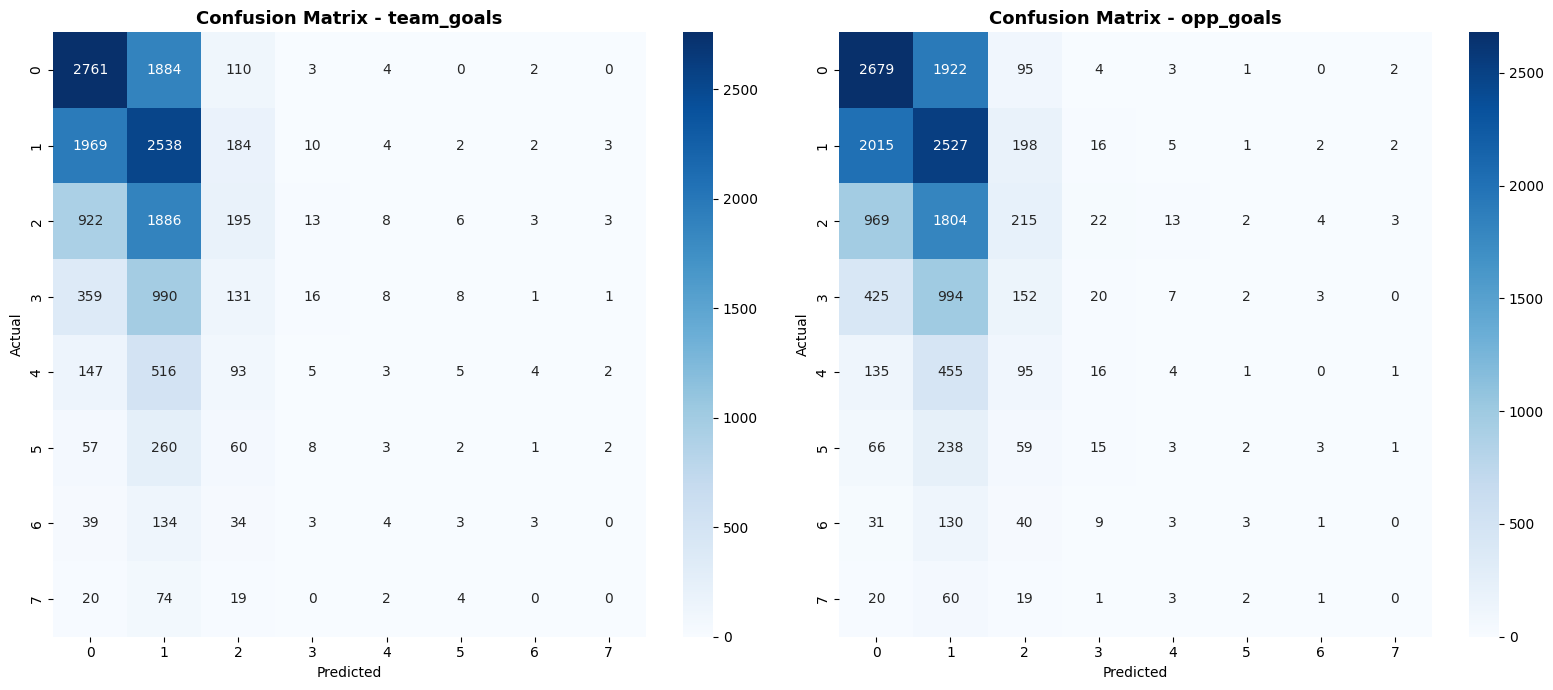

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, y_true_m, y_pred_m, title in zip(
    axes,
    [y_val['team_goals'][mask_team], y_val['opp_goals'][mask_opp]],
    [np.array(y_pred_team)[mask_team], np.array(y_pred_opp)[mask_opp]],
    ['team_goals', 'opp_goals']
):
    cm = confusion_matrix(y_true_m, y_pred_m)
    max_class = min(8, cm.shape[0])
    sns.heatmap(
        cm[:max_class, :max_class], annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=range(max_class), yticklabels=range(max_class)
    )
    ax.set_title(f'Confusion Matrix - {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

Hasil Prediksi

In [29]:
pred_team = model_team.predict(X_test_imp)
pred_opp  = model_opp.predict(X_test_imp)

id_col = test_df['Id'] if 'Id' in test_df.columns else range(len(pred_team))

submission = pd.DataFrame({
    'Id'        : id_col,
    'team_goals': pred_team,
    'opp_goals' : pred_opp
})

submission.to_csv('submission.csv', index=False)
print('Submission disimpan: submission.csv')
print('Verifying file creation:')
!ls -l submission.csv
print(f'Jumlah prediksi: {len(submission):,}')
display(submission.head(10))

Submission disimpan: submission.csv
Verifying file creation:
-rw-r--r-- 1 root root 907202 Jun 12 08:35 submission.csv
Verifying file creation:
-rw-r--r-- 1 root root 907202 Jun 12 08:35 submission.csv
Jumlah prediksi: 42,422


,Id,team_goals,opp_goals
0,M034984_Seychelles,0,1
1,M034984_Mauritius,1,1
2,M034985_Comoros,0,0
3,M034985_Maldives,1,0
4,M034986_Réunion,0,1
5,M034986_Madagascar,1,1
6,M034987_El Salvador,0,1
7,M034987_Venezuela,1,1
8,M034988_Mayotte,1,1
9,M034988_Réunion,1,1


In [26]:
# Download hasil submission
from google.colab import files
files.download('submission.csv')
print('Download submission.csv selesai!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download submission.csv selesai!


In [27]:
!pip install -q openpyxl

In [30]:
!pip install -q openpyxl

import os
from google.colab import files

pred_team = model_team.predict(X_test_imp)
pred_opp  = model_opp.predict(X_test_imp)

id_col = test_df['Id'] if 'Id' in test_df.columns else range(len(pred_team))

submission = pd.DataFrame({
    'Id'        : id_col,
    'team_goals': pred_team,
    'opp_goals' : pred_opp
})

# Simpan CSV dengan separator semicolon (agar Excel langsung baca 3 kolom)
submission.to_csv('submission.csv', index=False, sep=';')
print(f'✅ CSV tersimpan: {len(submission):,} baris')

# Simpan Excel (otomatis 3 kolom terpisah)
submission.to_excel('submission.xlsx', index=False, sheet_name='Predictions')
print(f'✅ Excel tersimpan: {len(submission):,} baris')

display(submission.head(10))

# Download keduanya
files.download('submission.csv')
files.download('submission.xlsx')
print('✅ Download selesai!')

✅ CSV tersimpan: 42,422 baris
✅ Excel tersimpan: 42,422 baris


,Id,team_goals,opp_goals
0,M034984_Seychelles,0,1
1,M034984_Mauritius,1,1
2,M034985_Comoros,0,0
3,M034985_Maldives,1,0
4,M034986_Réunion,0,1
5,M034986_Madagascar,1,1
6,M034987_El Salvador,0,1
7,M034987_Venezuela,1,1
8,M034988_Mayotte,1,1
9,M034988_Réunion,1,1


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download selesai!
